# Mouse Embryo Anaysis

### Download data

In [2]:
!uv init --python=3.8
!uv run python
!uv add stereopy --dev
!uv add ipykernel

Initialized project `stlens-tutorials`


you should put this code in main.py.

```
import stereo as st
import warnings
warnings.filterwarnings('ignore')

# read the GEF file
data_path = "./D05103C4D4.cellbin.gef"
data = st.io.read_gef(file_path=data_path, bin_type='cell_bins')
data.tl.raw_checkpoint()

# remember to set flavor as scanpy
adata = st.io.stereo_to_anndata(data, flavor='scanpy', output='scanpy_out.h5ad')
```

In [7]:
!uv run main.py

[2025-11-05 13:45:24][Stereo][3480830][MainThread][140003782453056][reader][1357][INFO]: read_gef begin ...
2025-11-05 13:45:24 [INFO   ] version is 1.1.22 
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1575][INFO]: This is GEF file which contains cell bin infomation.
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1576][INFO]: bin_type: cell_bins
2025-11-05 13:45:42 [INFO   ] version is 1.1.22 
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1582][INFO]: Number of cells: 1191339
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1585][INFO]: Number of gene: 29221
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1588][INFO]: Resolution: 500
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1591][INFO]: offsetX: 0
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1594][INFO]: offsetY: 0
[2025-11-05 1

In [10]:
!wget https://ftp.cngb.org/pub/stomics/STT0000124/supp/D05103C4D4.cellbin.gef -O D05103C4D4.cellbin.gef

--2025-11-05 13:50:41--  https://ftp.cngb.org/pub/stomics/STT0000124/supp/D05103C4D4.cellbin.gef
Resolving ftp.cngb.org (ftp.cngb.org)... 101.126.80.204
Connecting to ftp.cngb.org (ftp.cngb.org)|101.126.80.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4786769137 (4.5G) [application/octet-stream]
Saving to: ‘D05103C4D4.cellbin.gef’

D05103C4D4.cellbin. 100%[===================>]   4.46G   923KB/s    in 40m 59s 

2025-11-05 14:31:41 (1.86 MB/s) - ‘D05103C4D4.cellbin.gef’ saved [4786769137/4786769137]



### stLENS

In [ ]:
from stLENS import stLENS
stlens = stLENS()

/home/l202255179/micromamba/envs/stLENS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import scanpy as sc
adata = sc.read_h5ad('./scanpy_out.h5ad')
adata

AnnData object with n_obs × n_vars = 1191339 × 29221
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y'
    var: 'real_gene_name'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'cell_border', 'spatial'

In [ ]:
import scanpy as sc

adata.layers["counts"] = adata.X.copy()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=15)
adata

AnnData object with n_obs × n_vars = 660400 × 23683
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y', 'n_genes'
    var: 'real_gene_name', 'n_cells'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'cell_border', 'spatial'
    layers: 'counts'

/home/l202255179/micromamba/envs/stLENS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Using predefined sparsity: 0.999
[Warning] GPU memory insufficient. Falling back to CPU computation.
Max interactions exceeded!
lambda_c: 40.12057588488219
Number of signal: 139


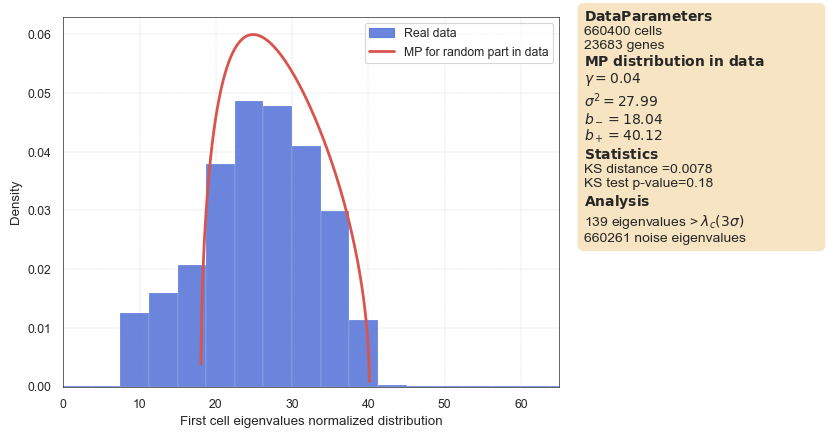

  0%|          | 0/20 [00:00<?, ?it/s]/home/l202255179/micromamba/envs/stLENS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
  5%|▌         | 1/20 [17:16<5:28:20, 1036.88s/it]/home/l202255179/micromamba/envs/stLENS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
 10%|█         | 2/20 [34:28<5:10:09, 1033.88s/it]/home/l202255179/micromamba/envs/stLENS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
 15%|█▌        | 3/20 [51:44<4:53:13, 1034.93s/it]/home/l202255179/micromamba/envs/stLENS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_val

number of filtered signals: 68


AnnData object with n_obs × n_vars = 660400 × 23683
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y', 'n_genes'
    var: 'real_gene_name', 'n_cells'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'stlens'
    obsm: 'cell_border', 'spatial'
    layers: 'counts'

In [ ]:
stlens_adata = stlens.find_optimal_pc(adata, plot_mp = True, device='gpu', tmp_directory='./output/stereoseq')
stlens_adata

In [ ]:
stlens_adata = stlens.pca(stlens_adata)
stlens_adata

AnnData object with n_obs × n_vars = 660400 × 23683
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y', 'n_genes'
    var: 'real_gene_name', 'n_cells'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'stlens'
    obsm: 'cell_border', 'spatial', 'X_pca_stlens'
    layers: 'counts'

In [ ]:
import scanpy as sc

sc.pp.neighbors(stlens_adata, use_rep='X_pca_stlens', metric='cosine')
sc.tl.umap(stlens_adata)

In [ ]:
sc.tl.leiden(stlens_adata)

/tmp/ipykernel_1298064/1054628897.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(stlens_adata)


/tmp/ipykernel_3873316/1976582718.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_stlens, color='leiden', spot_size=30, save="stlens_leiden_spatial_final.pdf")
saving figure to file figures/showstlens_leiden_spatial_final.pdf


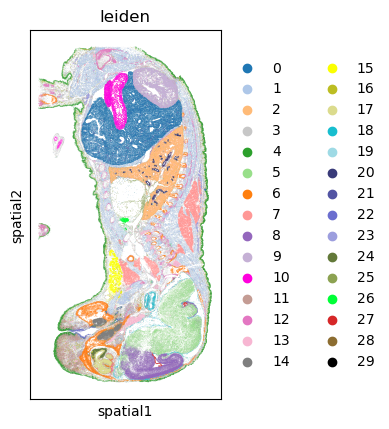

In [ ]:
sc.pl.spatial(stlens_adata, color='leiden', spot_size=30)

### Scanpy

In [ ]:
scanpy_ref = sc.read_h5ad("./scanpy_out.h5ad")
scanpy_ref

AnnData object with n_obs × n_vars = 1191339 × 29221
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y'
    var: 'real_gene_name'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'cell_border', 'spatial'

In [ ]:
import scanpy as sc

scanpy_ref.layers["counts"] = scanpy_ref.X.copy()
sc.pp.filter_cells(scanpy_ref, min_genes=200)
sc.pp.filter_genes(scanpy_ref, min_cells=15)
scanpy_ref

AnnData object with n_obs × n_vars = 660400 × 23683
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y', 'n_genes'
    var: 'real_gene_name', 'n_cells'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'cell_border', 'spatial'
    layers: 'counts'

In [ ]:
sc.pp.normalize_total(scanpy_ref)
sc.pp.log1p(scanpy_ref)

sc.pp.pca(scanpy_ref)
sc.pp.neighbors(scanpy_ref, use_rep='X_pca')
sc.tl.umap(scanpy_ref)
sc.tl.leiden(scanpy_ref)

/tmp/ipykernel_3873316/4208730378.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(scanpy_ref)


/tmp/ipykernel_3873316/959423081.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(scanpy_ref, color='leiden', spot_size=30, save="scanpy_ref_leiden_spatial_final.pdf")
saving figure to file figures/showscanpy_ref_leiden_spatial_final.pdf


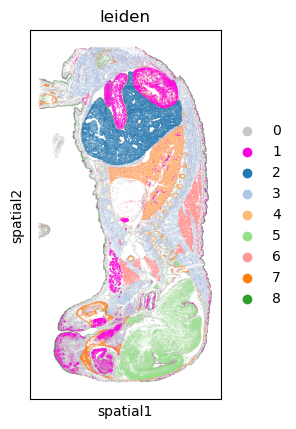

In [ ]:
sc.pl.spatial(scanpy_ref, color='leiden', spot_size=30)

### Kneed

In [ ]:
import scanpy as sc
adata_kn = sc.read_h5ad("./scanpy_out.h5ad")
adata_kn

AnnData object with n_obs × n_vars = 1191339 × 29221
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y'
    var: 'real_gene_name'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'cell_border', 'spatial'

In [ ]:
import scanpy as sc

adata_kn.layers["counts"] = adata_kn.X.copy()
sc.pp.filter_cells(adata_kn, min_genes=200)
sc.pp.filter_genes(adata_kn, min_cells=15)
adata_kn

AnnData object with n_obs × n_vars = 660400 × 23683
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y', 'n_genes'
    var: 'real_gene_name', 'n_cells'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'cell_border', 'spatial'
    layers: 'counts'

In [ ]:
import sys
!{sys.executable} -m pip install kneed

In [ ]:
import matplotlib.pyplot as plt
from kneed import KneeLocator, find_shape

In [ ]:
sc.pp.normalize_total(adata_kn)
sc.pp.log1p(adata_kn)
sc.pp.pca(adata_kn, n_comps=100)

In [ ]:
import numpy as np

y = adata_kn.uns['pca']['variance_ratio']
x = np.arange(1, len(y) + 1)

8


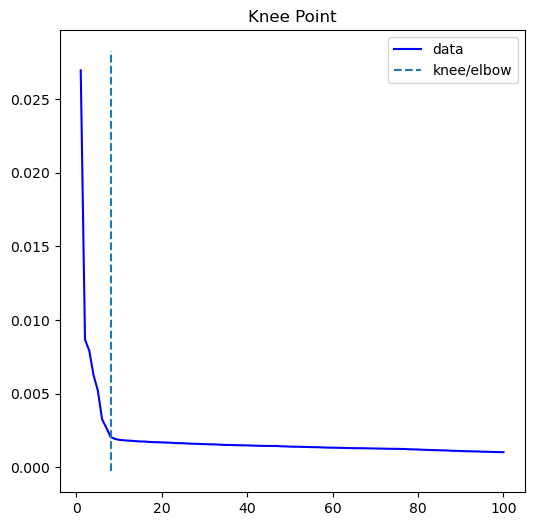

In [ ]:
direction, curve = find_shape(x, y)
kl = KneeLocator(x, y, curve=curve, direction=direction)
optimal_pc = int(kl.knee)  

print(kl.knee)
kl.plot_knee()

### optimal pc

/home/khyeonmin/micromamba/envs/stLENS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_2135676/3144573870.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_kn)
/tmp/ipykernel_2135676/3144573870.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_kn, color='leiden', spot_size=30)


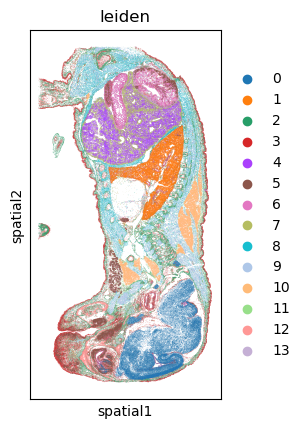

In [ ]:
sc.pp.neighbors(adata_kn, n_pcs=optimal_pc)
sc.tl.umap(adata_kn)
sc.tl.leiden(adata_kn)